# Stage 1–2 fixed-SIS FITS-PSF evaluation

This notebook evaluates weights produced by `train_HSC_PSF.py`. It uses the same fixed sparse SIS mappings, rebuilds the empirical/FITS PSF at the HR pixel scale, calls `model.eval()`, and compares the re-degraded prediction against both the observation and an explicit zero baseline.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

import data
from differentiable_lensing import DifferentiableLensing
from psf import apply_psf, build_psf_kernel
from sisr import SISR

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## Configuration
Use the same values that were passed to `train_HSC_PSF.py`.

In [7]:
WEIGHTS_PATH = Path('hsc_fits_psf_weights_O.pt')
PSF_PATH = Path('C:/Users/upraj/Prajwal/GSOC/DeepLense/Data/psf/psf/HSC_PSF/psf-calexp-pdr2_wide-HSC-I-15828-1,2-239.38410-42.10650.fits')
RESOLUTION = 0.168
PSF_SOURCE_PIXSCALE = 0.168
PSF_FITS_HDU = 0
PSF_FITS_EXTNAME = None
PSF_FITS_CROP_SIZE = None

MAGNIFICATION = 2
N_MAG = 1
RESIDUAL_DEPTH = 3
IN_CHANNELS = 2
LATENT_SPACE_SIZE = 64
IMAGE_SHAPE = 64
VAL_CLASS = 'no_sub'
VAL_INDEX = 0

EFFECTIVE_MAG = MAGNIFICATION ** N_MAG
TARGET_SHAPE = IMAGE_SHAPE * EFFECTIVE_MAG
TARGET_RESOLUTION = RESOLUTION / EFFECTIVE_MAG
assert WEIGHTS_PATH.exists(), WEIGHTS_PATH
assert PSF_PATH.exists(), PSF_PATH
print('LR/HR pixel scale:', RESOLUTION, TARGET_RESOLUTION)

LR/HR pixel scale: 0.168 0.084


In [8]:
# Rebuild the exact Stage 1–2 inference pipeline.
model = SISR(
    magnification=MAGNIFICATION, n_mag=N_MAG, residual_depth=RESIDUAL_DEPTH,
    in_channels=IN_CHANNELS, latent_channel_count=LATENT_SPACE_SIZE,
).to(DEVICE)
loaded = torch.load(WEIGHTS_PATH, map_location=DEVICE)
state_dict = loaded.get('model_state_dict', loaded) if isinstance(loaded, dict) else loaded
model.load_state_dict(state_dict)
model.eval()  # Required: BatchNorm must use stored running statistics.

lensing = DifferentiableLensing(
    device=DEVICE, alpha=None, target_resolution=TARGET_RESOLUTION, target_shape=TARGET_SHAPE,
).to(DEVICE)
forward_mappings = [
    torch.load('scatter_to_log_128.pt', map_location=DEVICE).to(DEVICE),
    torch.load('forward_from_log_128.pt', map_location=DEVICE).to(DEVICE),
    torch.load('scatter_from_log_128.pt', map_location=DEVICE).to(DEVICE),
]
backward_mapping = torch.load('sparse_grid_fracs_euclid_backward.pt', map_location=DEVICE).to(DEVICE)
psf_kernel = build_psf_kernel(
    psf_type='fits', fwhm_arcsec=0.16, pixscale_arcsec=TARGET_RESOLUTION,
    path=str(PSF_PATH), fits_hdu=PSF_FITS_HDU, fits_extname=PSF_FITS_EXTNAME,
    fits_crop_size=PSF_FITS_CROP_SIZE, source_pixscale_arcsec=PSF_SOURCE_PIXSCALE,
    device=DEVICE,
)
assert model.training is False
assert torch.isfinite(psf_kernel).all() and abs(float(psf_kernel.sum()) - 1.0) < 1e-5
print('PSF shape/sum:', tuple(psf_kernel.shape), float(psf_kernel.sum()))

PSF shape/sum: (81, 81) 1.0


C:\Users\upraj\AppData\Local\Temp\ipykernel_30676\88397592.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(WEIGHTS_PATH, map_location=DEVICE)
C:\User

In [9]:
dataset = data.LensingDataset('val/', [VAL_CLASS], 2000)
lr = dataset[VAL_INDEX].unsqueeze(0).float().to(DEVICE)
while lr.ndim > 4 and lr.shape[1] == 1:
    lr = lr.squeeze(1)
if lr.ndim == 3:
    lr = lr.unsqueeze(1)

with torch.inference_mode():
    source_lr = lensing.cross_grid_fill(lr, [backward_mapping])
    source_hr = model(torch.cat([source_lr, lr], dim=1))
    intrinsic_hr = lensing.cross_grid_fill(source_hr, forward_mappings)
    convolved_hr = apply_psf(intrinsic_hr, psf_kernel)
    degraded_lr = F.interpolate(convolved_hr, scale_factor=1.0 / EFFECTIVE_MAG, mode='area')
    residual_lr = degraded_lr - lr

zero_mse = F.mse_loss(torch.zeros_like(lr), lr)
model_mse = F.mse_loss(degraded_lr, lr)
skill_over_zero = 1.0 - model_mse / zero_mse.clamp_min(1e-12)
print('zero MSE:', float(zero_mse))
print('model MSE:', float(model_mse))
print('skill over zero:', float(skill_over_zero))

zero MSE: 0.006525034084916115
model MSE: 0.0023568435572087765
skill over zero: 0.638799786567688


In [10]:
def stats(name, x):
    x = x.detach()
    print(f'{name:24s} min={x.min().item():.5g} max={x.max().item():.5g} mean={x.mean().item():.5g} std={x.std().item():.5g} sum={x.sum().item():.5g}')

for name, tensor in [
    ('LR observation', lr), ('LR source', source_lr), ('HR source', source_hr),
    ('Intrinsic HR image', intrinsic_hr), ('PSF HR image', convolved_hr),
    ('Re-degraded LR', degraded_lr), ('LR residual', residual_lr),
]:
    stats(name, tensor)

LR observation           min=0 max=1 mean=0.01371 std=0.079615 sum=56.156
LR source                min=0 max=4.694 mean=0.0086654 std=0.10832 sum=35.493
HR source                min=0 max=7.0581 mean=0.02942 std=0.18465 sum=482.02
Intrinsic HR image       min=0 max=1.589 mean=0.025246 std=0.083965 sum=413.63
PSF HR image             min=0.0027967 max=0.59562 mean=0.024767 std=0.05164 sum=405.78
Re-degraded LR           min=0.0035531 max=0.58241 mean=0.024767 std=0.051318 sum=101.44
LR residual              min=-0.75069 max=0.20441 mean=0.011057 std=0.047277 sum=45.288


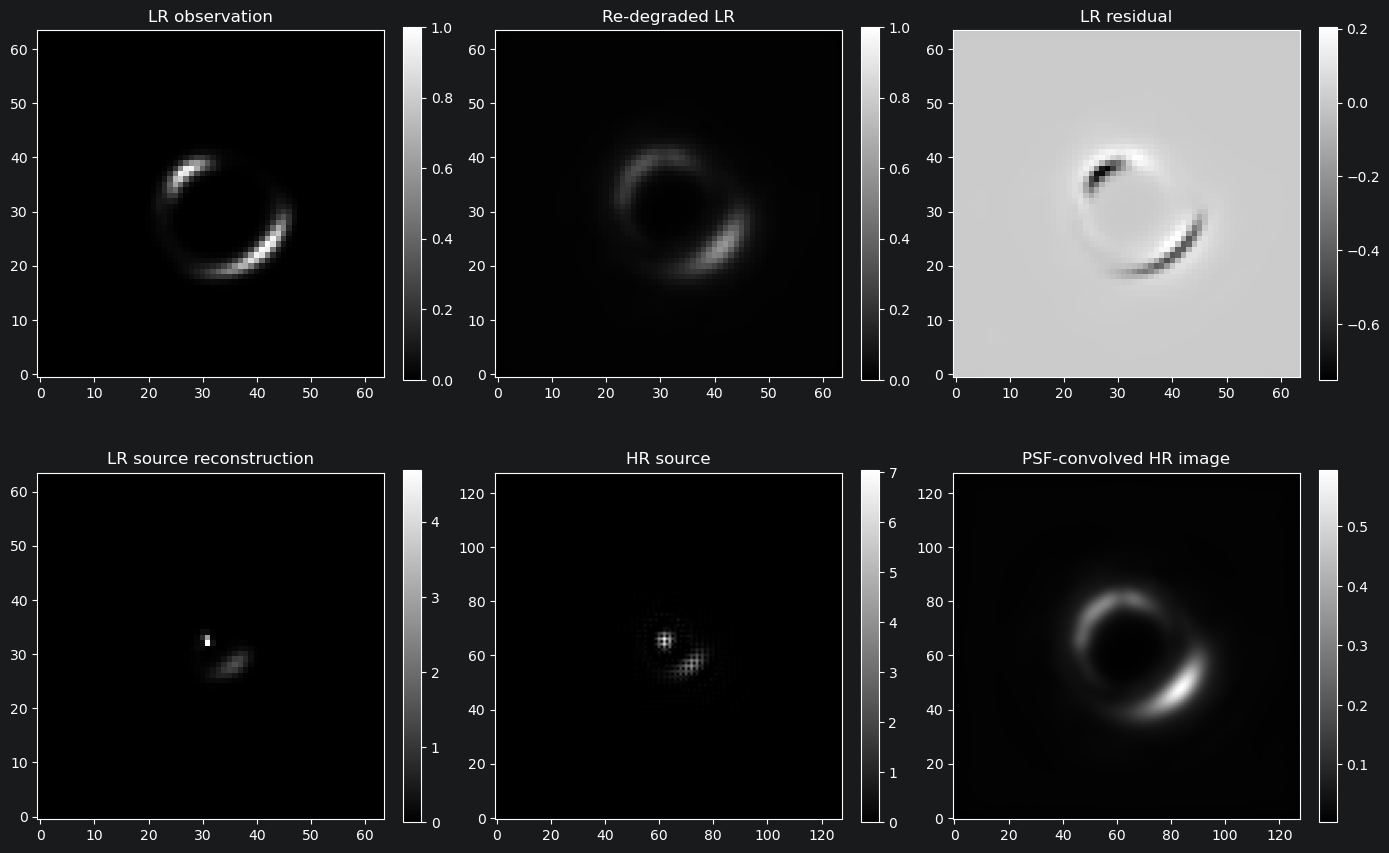

In [11]:
# Observation and prediction use one shared scale; latent/source panels use their own scales.
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
obs_vmin = min(float(lr.min()), float(degraded_lr.min()))
obs_vmax = max(float(lr.max()), float(degraded_lr.max()))
panels = [
    ('LR observation', lr[0, 0], obs_vmin, obs_vmax),
    ('Re-degraded LR', degraded_lr[0, 0], obs_vmin, obs_vmax),
    ('LR residual', residual_lr[0, 0], None, None),
    ('LR source reconstruction', source_lr[0, 0], None, None),
    ('HR source', source_hr[0, 0], None, None),
    ('PSF-convolved HR image', convolved_hr[0, 0], None, None),
]
for ax, (title, image, vmin, vmax) in zip(axes.flat, panels):
    im = ax.imshow(image.detach().cpu(), origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()